# Employee Attrition Prediction


First 5 Records
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptio

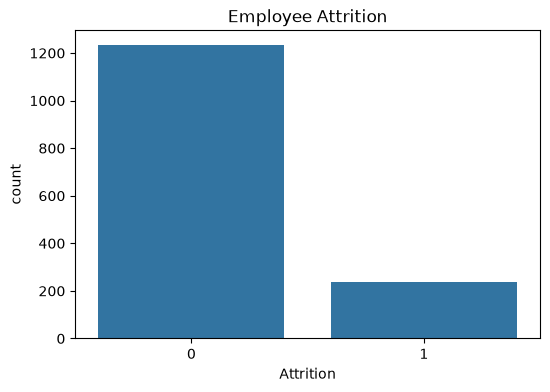

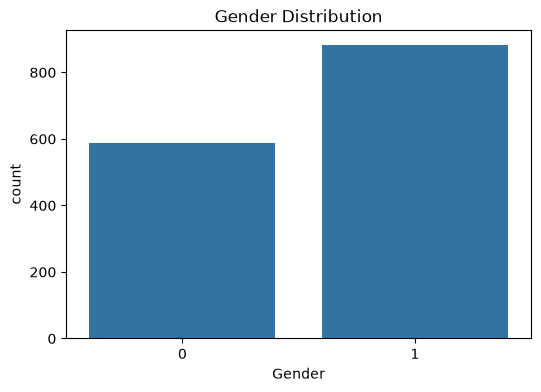

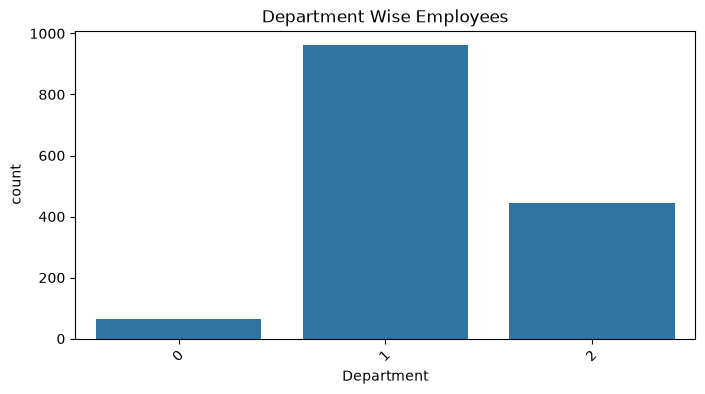

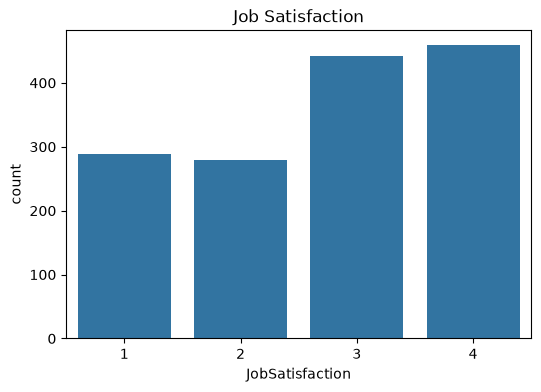

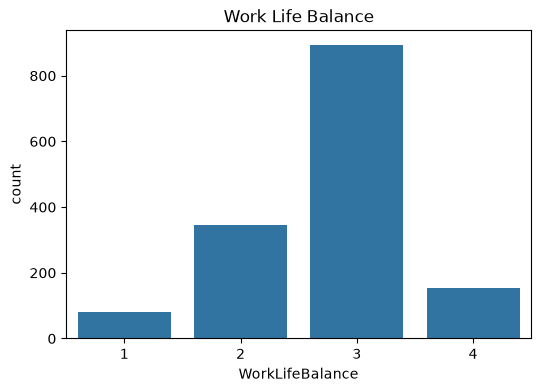

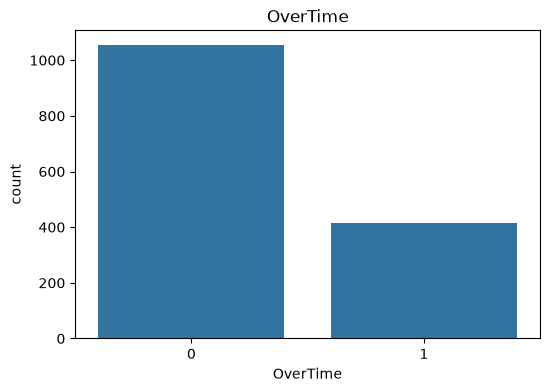

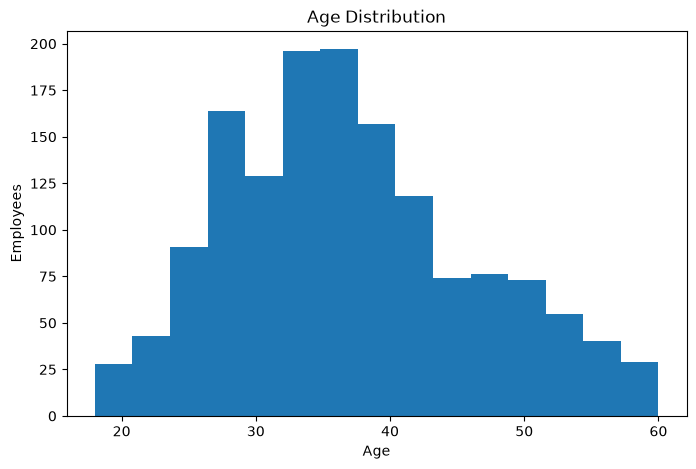

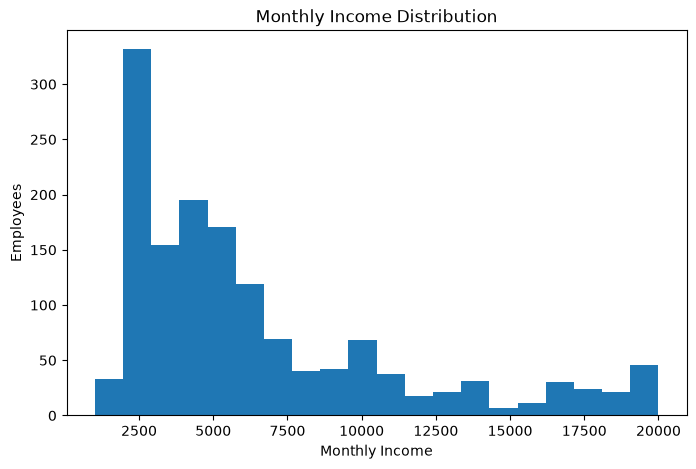

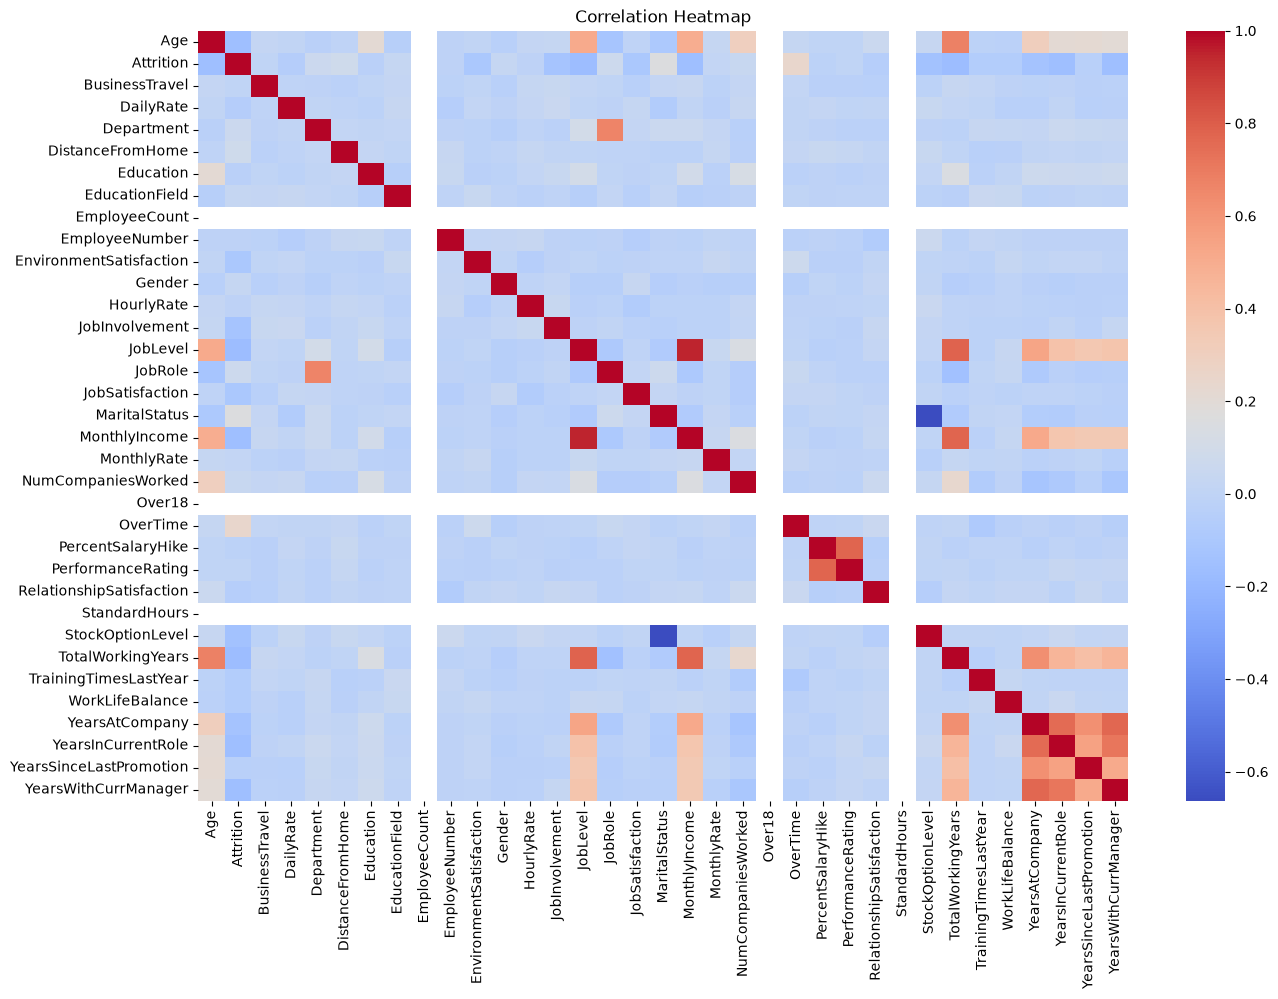


Logistic Regression Accuracy
0.891156462585034

Decision Tree Accuracy
0.7653061224489796

Random Forest Accuracy
0.8639455782312925

XGBoost Accuracy
0.8707482993197279

Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.891156   0.684211  0.333333  0.448276
1        Decision Tree  0.765306   0.159091  0.179487  0.168675
2        Random Forest  0.863946   0.444444  0.102564  0.166667
3              XGBoost  0.870748   0.529412  0.230769  0.321429

Best Model : Random Forest


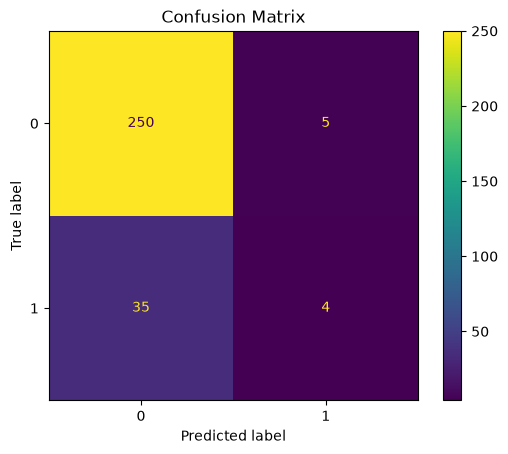


ROC AUC Score
0.7064353946706888


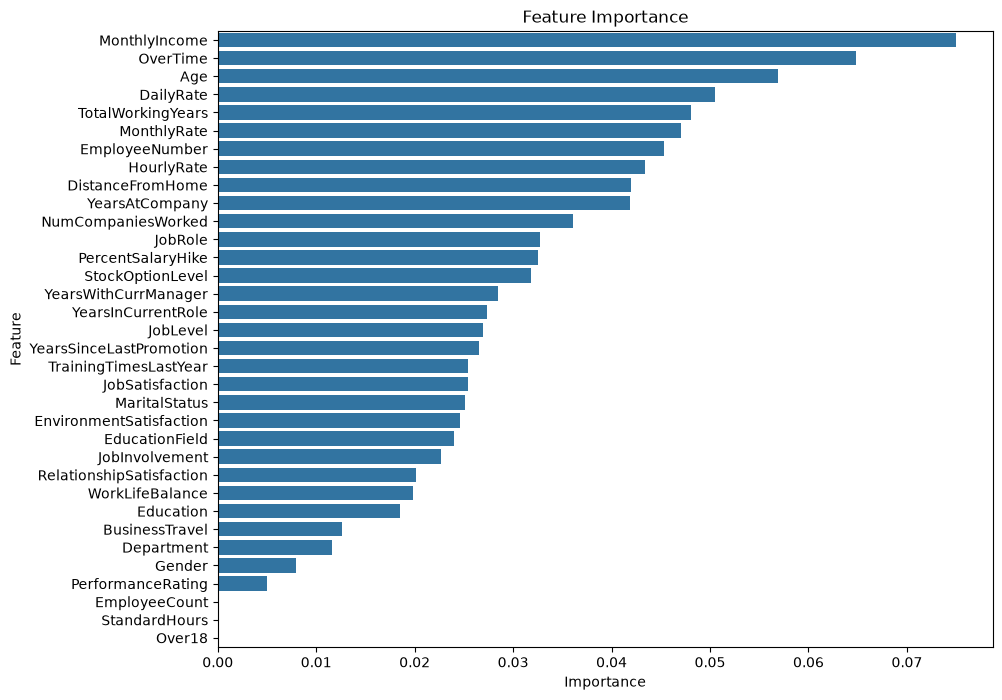


Model Saved Successfully

Prediction
Employee is likely to leave the company.

Random Forest Performance
Accuracy : 0.8639455782312925
Precision : 0.4444444444444444
Recall : 0.10256410256410256
F1 Score : 0.16666666666666666


In [4]:
# ==========================================
# Employee Attrition Prediction using ML
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================
# Data Preprocessing
# ==========================================

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x="Department", data=df)
plt.title("Department Wise Employees")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="JobSatisfaction", data=df)
plt.title("Job Satisfaction")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="WorkLifeBalance", data=df)
plt.title("Work Life Balance")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="OverTime", data=df)
plt.title("OverTime")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Employees")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["MonthlyIncome"], bins=20)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Employees")
plt.show()

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Feature Selection
# ==========================================

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# Logistic Regression
# ==========================================

lr = LogisticRegression(max_iter=5000, random_state=42)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy")
print(accuracy_score(y_test, pred_lr))

# ==========================================
# Decision Tree
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("\nDecision Tree Accuracy")
print(accuracy_score(y_test, pred_dt))

# ==========================================
# Random Forest
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy")
print(accuracy_score(y_test, pred_rf))

# ==========================================
# XGBoost
# ==========================================

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("\nXGBoost Accuracy")
print(accuracy_score(y_test, pred_xgb))

# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb)
    ],

    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_xgb)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_xgb)
    ],

    "F1 Score":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_xgb)
    ]

})

print("\nModel Comparison")
print(comparison)

# ==========================================
# Best Model
# ==========================================

best_model = rf

print("\nBest Model : Random Forest")

# ==========================================
# Confusion Matrix
# ==========================================

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

# ==========================================
# ROC AUC Score
# ==========================================

prob = rf.predict_proba(X_test)[:,1]

print("\nROC AUC Score")
print(roc_auc_score(y_test, prob))

# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

# ==========================================
# Save Model
# ==========================================

joblib.dump(best_model,"attrition_model.pkl")

print("\nModel Saved Successfully")



# Prediction
sample = X.iloc[[0]]
sample = scaler.transform(sample)
prediction = best_model.predict(sample)
print("\nPrediction")
if prediction[0] == 1:
    print("Employee is likely to leave the company.")
else:
    print("Employee is likely to stay in the company.")


# Final Evaluation
print("\nRandom Forest Performance")
print("Accuracy :", accuracy_score(y_test,pred_rf))
print("Precision :", precision_score(y_test,pred_rf))
print("Recall :", recall_score(y_test,pred_rf))
print("F1 Score :", f1_score(y_test,pred_rf))